In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
dataset = pd.read_csv("Mall_Customers.csv")
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
x = dataset.iloc[:,[3,4]].values

In [4]:
x

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

In [5]:
import warnings
warnings.filterwarnings("ignore")


In [45]:
from sklearn.cluster import OPTICS
clustering = OPTICS(metric='cityblock',cluster_method='xi', p=2,eps=None, xi=0.05,predecessor_correction=True, min_cluster_size=None, 
                    algorithm='auto', leaf_size=30, memory=None, n_jobs=None)
label = clustering.fit_predict(x)



In [46]:
clustering.labels_

array([-1,  5,  6,  5, -1,  5,  6, -1,  6,  5,  6, -1,  6,  5,  6,  5,  0,
        5,  0, -1,  0,  5,  6,  5,  6,  5,  0, -1,  0,  5,  6,  5,  6,  5,
        6,  5, -1,  5, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1,
       -1, -1, -1, -1, -1,  1, -1,  1, -1, -1, -1,  1, -1,  1, -1,  1,  1,
       -1,  1, -1, -1,  1, -1,  2,  2,  2,  2,  2, -1,  2,  2, -1, -1,  2,
       -1, -1,  2, -1, -1, -1,  3,  3,  3,  3, -1,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3, -1,  3,
       -1, -1,  3, -1, 10,  4,  9,  4, 10, -1,  9,  7,  9,  4,  9,  7, 10,
        7,  9,  7,  9,  7, 10,  4, 10, -1, 10,  4,  9, -1, 10, -1, 10, -1,
        9, -1, 10,  7,  9,  7,  9,  4,  9,  7, 10, -1, -1, -1, 10, -1, -1,
        8, -1,  8, 10,  8, -1,  8, -1,  8, -1, -1, -1,  8, -1, -1, -1,  8,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [47]:
#convert to supervised
supervised = pd.DataFrame(dataset)
supervised['cluster_group'] = label
supervised

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster_group
0,1,Male,19,15,39,-1
1,2,Male,21,15,81,5
2,3,Female,20,16,6,6
3,4,Female,23,16,77,5
4,5,Female,31,17,40,-1
...,...,...,...,...,...,...
195,196,Female,35,120,79,-1
196,197,Female,45,126,28,-1
197,198,Male,32,126,74,-1
198,199,Male,32,137,18,-1


In [48]:
supervised.to_csv('cluster.csv',index=False)

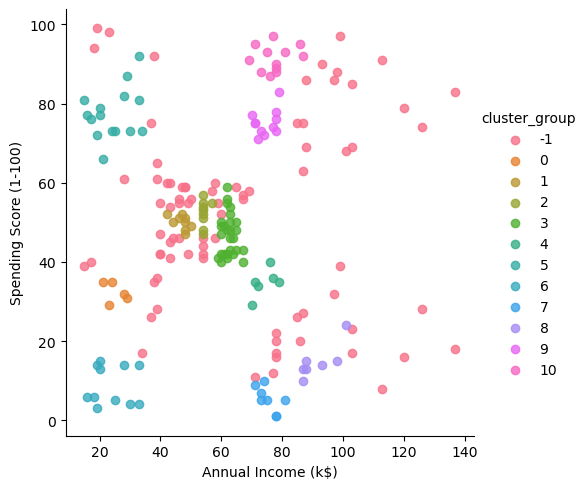

In [49]:
import seaborn as sns 
facet = sns.lmplot(data= supervised, x=supervised.columns[3], y=supervised.columns[4], hue=supervised.columns[5],fit_reg=False,
                   legend=True,legend_out=True)
                   